# اشتقاق الخصائص وتوصيفها:
2016-00-04 13:55:08 

## فهم الخصائص:

### الهدف:
سنحاول ان نفهم هنا , ماهي الخصائص , ولماذا هي هامة  ,ولماذا الزوايا هامة.

### الشرح:

كيف يمكن للانسان عموماً , تميز القطع المنفصلة المشكلة للصورة الواحدة؟ وهل يمكن للحاسب نظرياً امتلاك هكذا قدرة ؟ 
وإذا أمكن هذا لماذا لا يمكننا انشاء تطبيقات تفعل أكثر وتجمع كل الصور لمشهد واحد مع بعضها, أو يمكنها أيضاً انشاء نموذج ثلاثي الابعاد من مجموعة صور لمجسم.

السؤال المطروح أعلاه يتمركز بالنقطة الاساسية وهي كيف لحاسب تجميع صور مختلفة لنفس المشهد .


والجواب له يكون بايجاد خصائص محددة فريدة يمكن تتبعها , وفيما لو أردنا تعريف هكذا خصائص نرى أننا نتصور مفهومه نظرياً , ويمكن لنا أن نحددها ضمن صورة تلقائياً حيث أن هذه الموهبة موجودة لدى الاطفال اللاعبين بلعبة الصور المفككة حيث يمكنهم تجميع القطع وتحديد التشابه فيها .. الخ ...

والسؤال هو ** ما هي هذه الخصائص؟ ** والجواب يجب أن يكون مفهوماً من قبل الحاسب ..

فلنأخذ المثال التالي:

<img src="../../images/less21.png"/>

نلاحظ ان القطع اعلاه من F - A هي موجودة ضمن الصورة ولكن أيها أسهل و أفضل لهكذا عمل , نرى بوضوح أن المقاطع ذات النسيج الموحد لا تكفي , ولا تلك التي تمثل الحواف D - C , وانما الافضل هو الزوايا E - F حيث يمكن تمييزها عند تحركها بأي اتجاه...


ولذلك بعد الاجابة على السؤال الاول ؟ نسأل " كيف نجد تلك الخصائص ؟" ونجيب عليه أيضاً من خلال الحدس , حيث أن تلك المناطق تتغير أكثر من غيرها عند تحريكها , ونعبر عن هذا بلغة الحاسوب بما يسمى ** اكتشاف الخصائص ؟**

والان بعد ايجاد الخصائص , فرضاً , علينا مطابقتها مع خصائص أخرى بصور اخرى , ويتم ذلك بأخذ منطقة حول الخاصية ووصفها , أي وصف الخاصية وبشكل مشابه يقوم الحاسب بذلك ..  ويسمى هذا وصف الخاصية , وبعد الخصول على الخاصية  والوصف يتم استخدام ذلك , إما لترتيب الخصائص أو لوصل الصور..
والتالي سيشرح عن خوارزميات مطبقة في OpenCV لفعل كل المهام السابقة ..


### مراجع اضافية:

### تمارين 


## اكتشاف زوايا هاريس :

### الهدف:
** بهذا الفصل :**

* سنتعرف على الفكرة وراء اكتشاف زوايا هارييس.

* سنرى التوابع : **cv2.cornerHarris , cv2.cornerSubPix**

### النظرية:

في هذه الخوارزمية تم تحويل الافكار البسيطة السابقة حول الخصائص لصيغة رياضية . وجوهرياً يتم حساب الاختلاف بالشدة عند التحريك ب $(u,v)$ بكل الاتجاهات كالتالي:


$$ E(u,v) = \sum_{\text{x,y}}{\;\underbrace{w(x,y)}_{\text{window function}} \;[\underbrace{I(x+u,y+v)}_{\text{shifted intensity}}-\underbrace{I(x,y)}_{\text{intensity}}]^2 }$$

تابع النافذة , إما نافذة مستطيلة أو غاوسية , والتي تعطي أوزاناً للبكسلات أدناها.

وعلينا تعظيم قيمة $E(u,v)$ لايجاد الزوايا وهذا يعني أنه علينا تعظيم الحد الثاني بتطبيق منشور تايلو على المعادلة أعلاه , وباستخدام بعض الخطوات البسيطة نحصل على مايلي:

$$E(u,v) \approx \begin{bmatrix}
u & v \\
\end{bmatrix} \; M \; \begin{bmatrix} u \\
v \\
\end{bmatrix}
$$

حيث:

$$ M = \sum_{x,y} w(x,y) \begin{bmatrix} 
I_x I_x & I_x I_y \\
I_x I_y & I_y I_y \\
\end{bmatrix} $$

وهنا $$ I_y ,I_x $$ هي مشتقات الصورة بالاتجاهات x,y يمكن ايجادها باستخدام cv2.sobel..

وهنا تأتي الخطوة الرئيسية , حيث نقوم بانشاء سجل , تحديداً معادلة لنافذة تحدد هل ممكن وجود زاوية فيها أم لا.

$$R = det(M) - k(trace(M))^2 $$

** حيث : **

* $$ det(M) = \lambda_1 \lambda_2 $$

* $$ trace(M) = \lambda_1 + \lambda_2 $$

* $$ \lambda_1 and \ \lambda_2 $$ 
هي القيم الذاتية من
M.

ولذلك قيم تلك المتغيرات هي التي تحدد اذا كانت المنطقة , زاوية أو حافة أو مستوي.

 * حيثما R صغيرة , المنطقة مستوية .
 
 * وحيث R سالبة فالمنطقة حافة
 
 * وحيث R كبيرة , فالمنطقة زاوية.
 
 
 ولنلحظ ان نتيجة الكاشف هو صورة مستوية رمادية , واخذ العتبة لها بشكل مناسب , يعطي الزوايا بالصورة . والتالي مثال:

## مكتشفات الزوايا لهاريس في OpenCV:

يتم ذلك من خلال التابع :
**cv2.cornerHarris ** ومداخله هي:

* img : صورة الدخل بصيغة float32.

* blockSize : قياس الجوار بالنسبة لاكتشاف الحواف.

* ksize : بارامتر الفتحة لمشتق سوبول.

* k : البارامتر الحر لمكتشف هاريس في المعادلة.

راقب المثال أدناه :

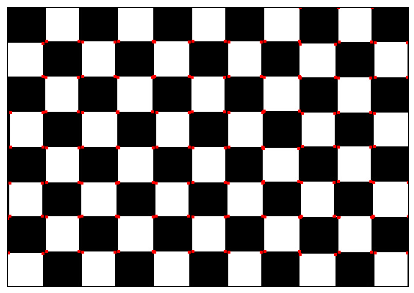

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

filename = 'chessboard1.jpg'
img = cv2.imread(filename)
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)


gray = np.float32(gray)
dst = cv2.cornerHarris(gray,2,3,0.04)

#result is dilated for marking the corners, not important
dst = cv2.dilate(dst,None)

# Threshold for an optimal value,
# it may vary depending on the image.
img[dst>0.01*dst.max()]=[255,0,0]

plt.figure(figsize= (10,5))
plt.imshow(img , cmap='gray')
plt.xticks([]),  plt.yticks([])
plt.show()

### الزوايا بدقة بكسل ملحق , SubPixel:
احياناً , نحتاج لدقة أكبر لذلك نمرر ناتج اكتشاف هاريس , للتابع **cv2.cornerSubPix ** والذي يرشح الناتج , للحصول على نتائج أدق.

### مراجع اضافية

### تمارين:

# مكتشف الزوايا Shi-Tomasi والخصائص المناسبة للتعقب:

### الهدف :
هنا سنتعلم:

* مكتشف زوايا جديد.

* سنرى التابع : **cv2.goodFeaturesToTrack **



### النظرية:

 في مكتشف هاريس , تم أخذ تابع التحصيل كالتالي:
 
 $$R = \lambda_1 \lambda_2 - k(\lambda_1 + \lambda_2)^2 $$
 
 بدلاً عن ذلك اقترح Shi-Tomasi التالي:
 
 $$ R = min(\lambda_1 ,\lambda_2) $$
 
 ثم اذا كانت اكبر من قيمة معينة نعدها زاوية , ومنه نرى انه فقط اذاكانت القيم السابقة اكبر من حد معين $ \lambda_{min} $ كلها فنعدها زاوية.
 
 ### الكود:
 
 لدى OpenCV التابع **cv2.goodFeaturesToTrack ** . الذي يجد النقاط الاقوى المطلوبة , كما يأخذ حداً ادنى لنوعية الزاوية وكذلك المسافة الاقليدية الاصغرية بين الزوايا التي ترفض القيم ما دونها , وبالنهاية نحصل على مصفوفة لاقوى N زاوية بالصورة الرمادية الممررة.



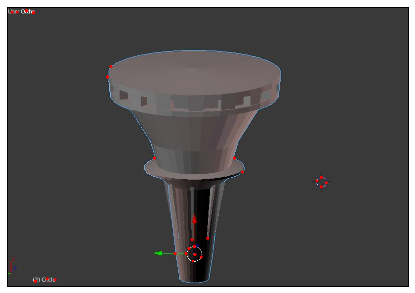

In [3]:
img = cv2.imread('wt.jpg')
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

corners = cv2.goodFeaturesToTrack(gray,25,0.01,10)
#number of features, quality , min dist between features
corners = np.int0(corners)

for i in corners:
    x,y = i.ravel()
    cv2.circle(img,(x,y),3,255,-1)

gray = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

plt.figure(figsize= (10,5))
plt.imshow(img , cmap='gray')
plt.xticks([]),  plt.yticks([])
plt.show()

وهذا التابع مناسب أكثر للتعقب , كما سنرى.

### المراجع الاضافية 

### التمارين